# **Seasonal Agriculture Performance Analysis**

## Major Data Analytics Project

Domain: Agriculture                                 
Project Theme: Seasonal Agriculture Performance              
Tools: Python, Pandas, NumPy, Matplotlib, Seaborn-style exploratory analysis, SciPy

Dataset: Supplied seasonal agriculture performance CSV                 
Records: 4000    Variables: 28


## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource
availability and economic conditions. As a result, agricultural performance may differ from one season to another.
The objective is to analyze the supplied agricultural dataset and investigate seasonal differences in agricultural
performance by identifying meaningful patterns, trends, relationships and variations within the available data.
The analysis follows the project brief: understand and clean the data, examine seasonal performance, compare
relevant groups, investigate relationships, apply suitable statistical/visual techniques, and develop evidence-based
conclusions and recommendations.

## 2. Project Objectives
* Understand the structure and quality of the agricultural dataset.
* Clean and prepare the data for analysis.
* Explore seasonal patterns in the dataset.
* Perform descriptive and statistical analysis.
* Investigate relationships among relevant variables.
* Compare agricultural performance across seasons and other meaningful groups.
* Use appropriate univariate, bivariate and multivariate visualizations.
* Identify significant findings, unusual patterns and practical recommendations.

## 3. Dataset

The dataset contains farm-level agricultural records covering seasons, locations, crops, environmental conditions,
farming practices, production, costs, revenue, profit and resource usage.

The supplied CSV contains 4,000 rows and 28 columns. The analysis below uses that dataset directly.

In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
# Load the dataset
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (4000, 28)


## 4. Initial Data Understanding

The first stage is to inspect the shape, sample rows, column information, data types and numerical summary statistics

## 4.1 Dataset Shap

In [ ]:
# Dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


## 4.2 First Five Rows

In [ ]:
# Top 5 rows
df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## 4.3 Column Information and Data Types

In [ ]:
# Column information and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

The dataset contains categorical/text fields such as Farm_ID, State, District, Crop, Season and Irrigation_Method,
along with numeric environmental, input, production and financial variables

## 4.4 Summary Statistic

In [34]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"4,000.00",600.71,288.43,80.00,370.43,581.00,836.12,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"4,000.00",26.50,6.70,8.00,21.70,26.40,31.20,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


## 5. Data Quality and Cleaning

Before analysis, missing values and duplicate records are checked. The supplied dataset contains missing values in
Rainfall_mm, Soil_Moisture_pct and Yield_Tonnes_Ha.

In [ ]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 5.1 Missing-Value Treatment

In [14]:
# Fill missing numeric values using the median within each season
for col in ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]:
    df[col] = df.groupby("Season")[col].transform(
        lambda s: s.fillna(s.median())
    )
print(df[["Rainfall_mm", "Soil_Moisture_pct",
          "Yield_Tonnes_Ha"]].isnull().sum())

Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64


Season-wise median imputation is used so that missing environmental/yield values are replaced using the distribution
of the same season. No rows are dropped, so the sample remains 4,000 records

## 5.2 Category Checks

In [5]:
# Check category values
for col in ["Season", "Crop", "State", "Irrigation_Method"]:
    print("\n", col)
    print(df[col].value_counts())


 Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

 Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

 State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

 Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


The main categorical fields contain 3 seasons, 8 crops, 8 states and 4 irrigation methods.

## 6. Seasonal Performance Overview

Season is the central analytical dimension of the project. The following summary compares production, yield, revenue,
profit, water use and water efficiency.

In [8]:
# Seasonal performance summary
season_summary = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Production=("Production_Tonnes", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).reindex(["Kharif", "Rabi", "Zaid"]).round(2)
season_summary

,Records,Avg_Yield,Avg_Production,Avg_Revenue,Avg_Profit,Avg_Water,Avg_Water_Efficiency
Season,,,,,,,
Kharif,1779,5.64,46.31,"710,719.06","178,914.65","6,102.20",5.89
Rabi,1627,5.08,41.49,"601,526.05","87,689.47","5,846.99",5.19
Zaid,594,4.67,38.89,"519,171.90","-24,804.82","6,419.89",4.41


## 6.1 Seasonal Record Distribution

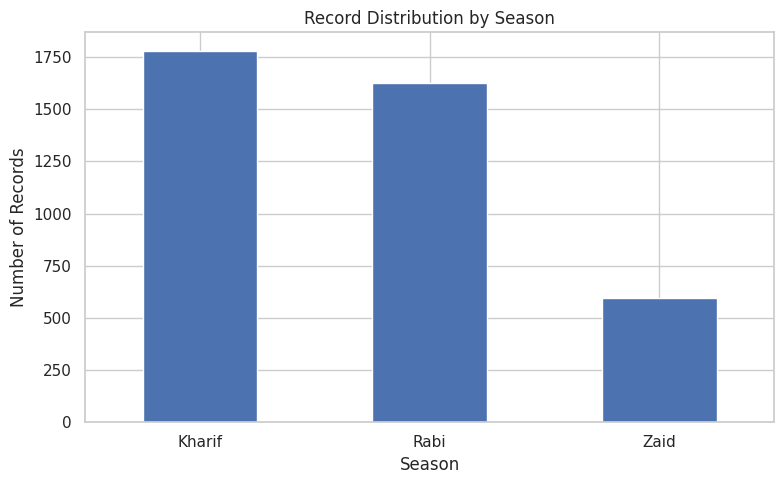

In [9]:
# Record distribution by season
season_counts = df["Season"].value_counts().reindex(
    ["Kharif", "Rabi", "Zaid"]
)
plt.figure(figsize=(8, 5))
ax = season_counts.plot(kind="bar")
plt.title("Record Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Kharif has 1779 records (44.5%), Rabi has 1627 (40.7%), and Zaid has 594 (14.8%). Because group sizes differ, mean
values and rates are more appropriate than raw totals for season comparison.

## 6.2 Yield Distribution by Season

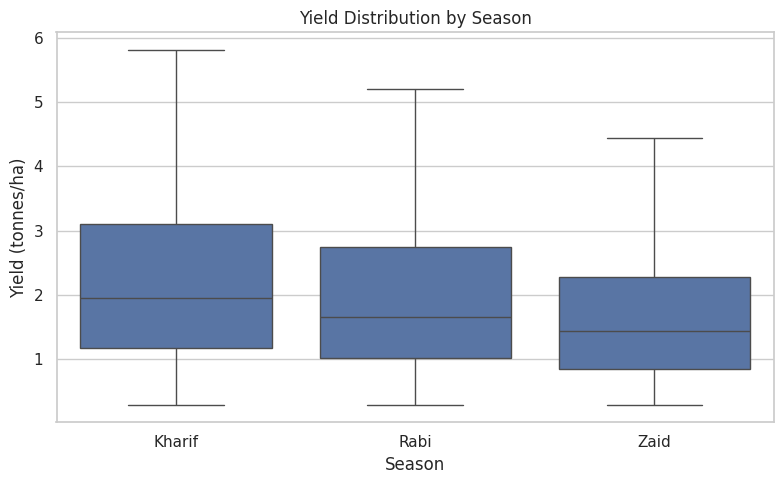

In [10]:
# Yield distribution by season
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    order=["Kharif", "Rabi", "Zaid"],
    showfliers=False
)
plt.title("Yield Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

Mean yield is highest in Kharif (5.63 t/ha), followed by Rabi (5.04) and Zaid (4.64). The distribution is influenced by
crop mix, particularly high-yield crops such as sugarcane.

## 6.3 Economic Outcomes Across Seasons

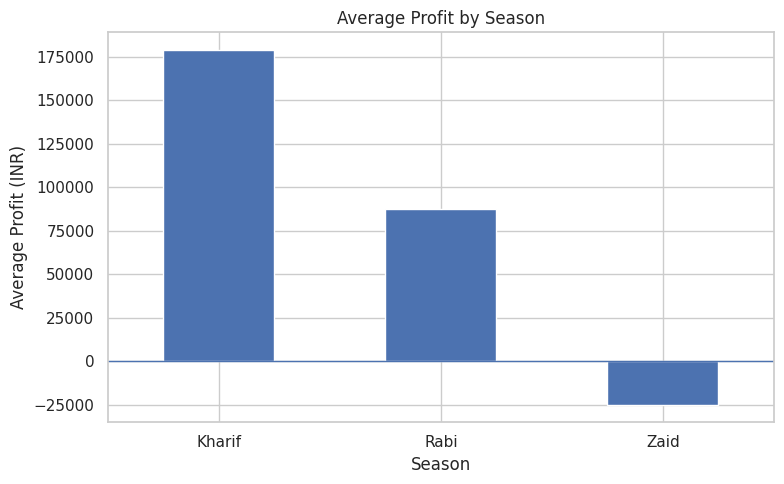

In [11]:
# Average profit by season
profit_by_season = df.groupby("Season")["Profit_INR"].mean().reindex(
    ["Kharif", "Rabi", "Zaid"]
)
plt.figure(figsize=(8, 5))
profit_by_season.plot(kind="bar")
plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

In [12]:
# Profitability rate by season
profitability = (
    df.groupby("Season")["Profit_INR"]
      .apply(lambda s: (s > 0).mean() * 100)
      .reindex(["Kharif", "Rabi", "Zaid"])
)
profitability.round(2)

,Profit_INR
Season,
Kharif,57.79
Rabi,48.86
Zaid,35.52


Average profit declines from INR 178,915 in Kharif to INR 87,689 in Rabi and INR -24,805 in Zaid. Profitability rates are
57.8%, 48.9% and 35.5% respectively.

## 6.4 Seasonal Environmental Conditions

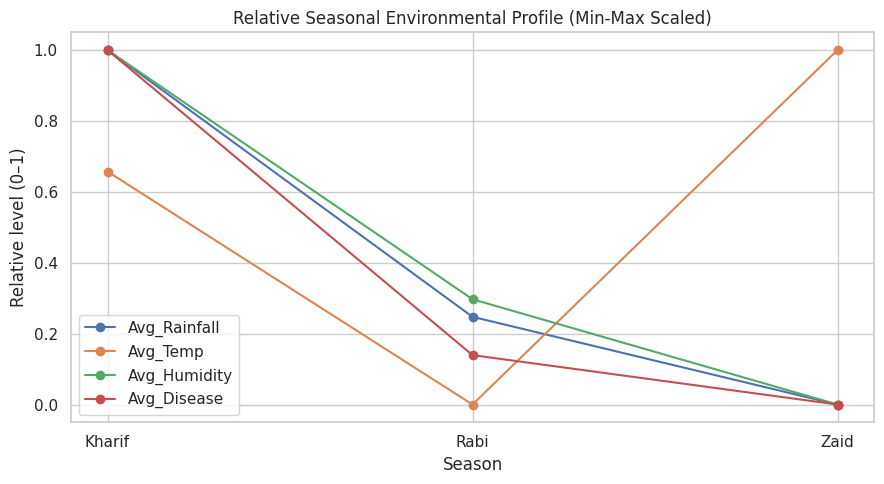

,Avg_Rainfall,Avg_Temp,Avg_Humidity,Avg_Disease
Season,,,,
Kharif,852.11,28.45,71.81,54.47
Rabi,435.94,23.49,57.89,40.48
Zaid,299.12,31.04,52.01,38.22


In [16]:
# Relative environmental profile
env = df.groupby("Season").agg(
    Avg_Rainfall=("Rainfall_mm", "mean"),
    Avg_Temp=("Avg_Temperature_C", "mean"),
    Avg_Humidity=("Humidity_pct", "mean"),
    Avg_Disease=("Disease_Pest_Risk_pct", "mean")
).reindex(["Kharif", "Rabi", "Zaid"])
env_scaled = (env - env.min()) / (env.max() - env.min())
plt.figure(figsize=(9, 5))
for col in env_scaled.columns:
    plt.plot(env_scaled.index, env_scaled[col],
             marker="o", label=col)
plt.title("Relative Seasonal Environmental Profile (Min-Max Scaled)")
plt.xlabel("Season")
plt.ylabel("Relative level (0–1)")
plt.legend()
plt.tight_layout()
plt.show()

env

Kharif is the wettest and most humid season (average rainfall 852.1 mm; humidity 71.8%). Zaid is the hottest and driest
(temperature 31.0 °C; rainfall 299.1 mm). Disease/pest risk is highest in Kharif at 54.5%.

## 7. Crop-Level Performance

Seasonal averages can be affected by crop composition. Therefore, crop-level profit, yield and profitability are
examined separately.

In [17]:
# Crop-level comparison
crop_summary = df.groupby("Crop").agg(
    Records=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Profitability=("Profit_INR", lambda s: (s > 0).mean() * 100)
).sort_values("Avg_Profit", ascending=False)
crop_summary.round(2)

,Records,Avg_Yield,Avg_Profit,Profitability
Crop,,,,
Sugarcane,305,46.64,"817,187.99",88.52
Chilli,412,1.54,"750,878.34",82.04
Cotton,508,1.23,"124,546.92",65.35
Groundnut,424,1.32,"44,858.12",59.20
Pulses,496,0.92,"-4,238.05",50.81
Maize,551,2.71,"-83,978.33",36.30
Rice,690,2.43,"-102,213.50",33.62
Wheat,614,2.11,"-123,398.34",25.90


## 7.1 Average Profit by Crop

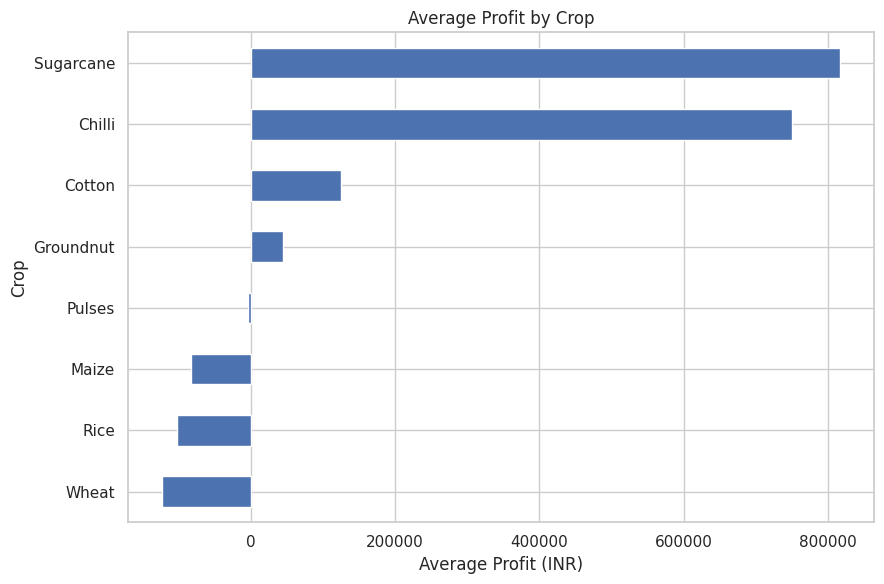

In [18]:
# Average profit by crop
plt.figure(figsize=(9, 6))
crop_summary["Avg_Profit"].sort_values().plot(kind="barh")
plt.title("Average Profit by Crop")
plt.xlabel("Average Profit (INR)")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

Sugarcane and Chilli have the highest average profits. In contrast, wheat, rice and maize have negative average profit
in this dataset. This shows why crop-specific analysis is necessary before interpreting overall seasonal performance.

## 8. Resource Usage and Irrigation

Irrigation method is compared using yield, profit, water use, water efficiency and profitability.

In [19]:
# Irrigation method comparison
irrigation_summary = df.groupby("Irrigation_Method").agg(
    Records=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water=("Water_Used_m3", "mean"),
    Avg_Eff=("Water_Efficiency_t_per_1000m3", "mean"),
    Profitability=("Profit_INR", lambda s: (s > 0).mean() * 100)
).sort_values("Avg_Profit", ascending=False)
irrigation_summary.round(2)

,Records,Avg_Yield,Avg_Profit,Avg_Water,Avg_Eff,Profitability
Irrigation_Method,,,,,,
Drip,915,6.58,"219,626.00","5,918.75",6.27,59.78
Sprinkler,734,5.16,"91,121.08","6,208.26",4.67,51.91
Rainfed,1041,4.60,"79,050.37","3,549.55",7.56,46.88
Flood,1310,4.86,"73,354.02","8,026.47",3.44,47.18


## 8.1 Average Water Efficiency by Irrigation Method

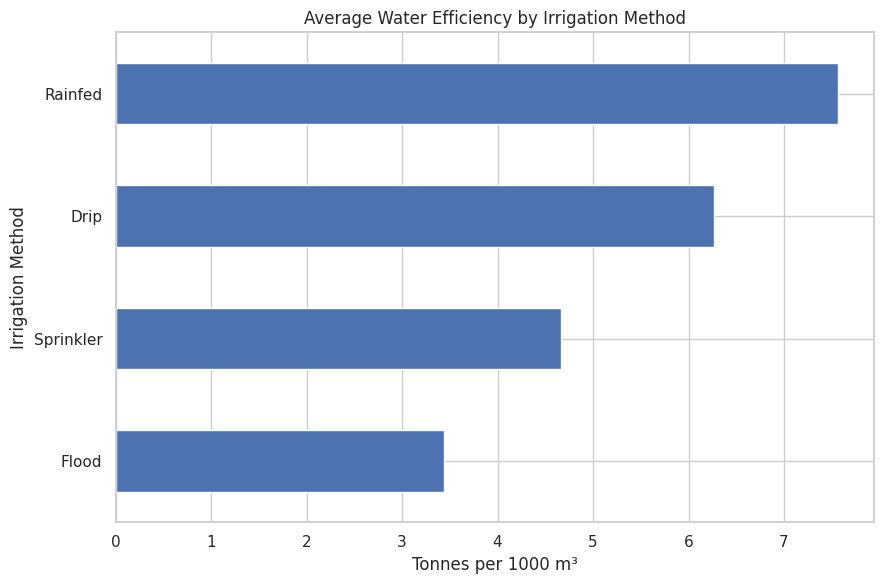

In [20]:
# Average water efficiency by irrigation method
plt.figure(figsize=(9, 6))
irrigation_summary["Avg_Eff"].sort_values().plot(kind="barh")
plt.title("Average Water Efficiency by Irrigation Method")
plt.xlabel("Tonnes per 1000 m³")
plt.ylabel("Irrigation Method")
plt.tight_layout()
plt.show()

Drip has the highest average yield (6.58 t/ha) and Drip has the highest average profit (INR 219,626). Rainfed has the
highest average water-efficiency ratio (7.56), while Flood has the lowest (3.44). These are descriptive associations, not
causal effects, because crop, farm size and season differ across irrigation groups.

## 9. Relationships Between Variables

Correlation analysis is used to identify linear relationships among numeric variables. Correlation should be interpreted
as association, not causation.

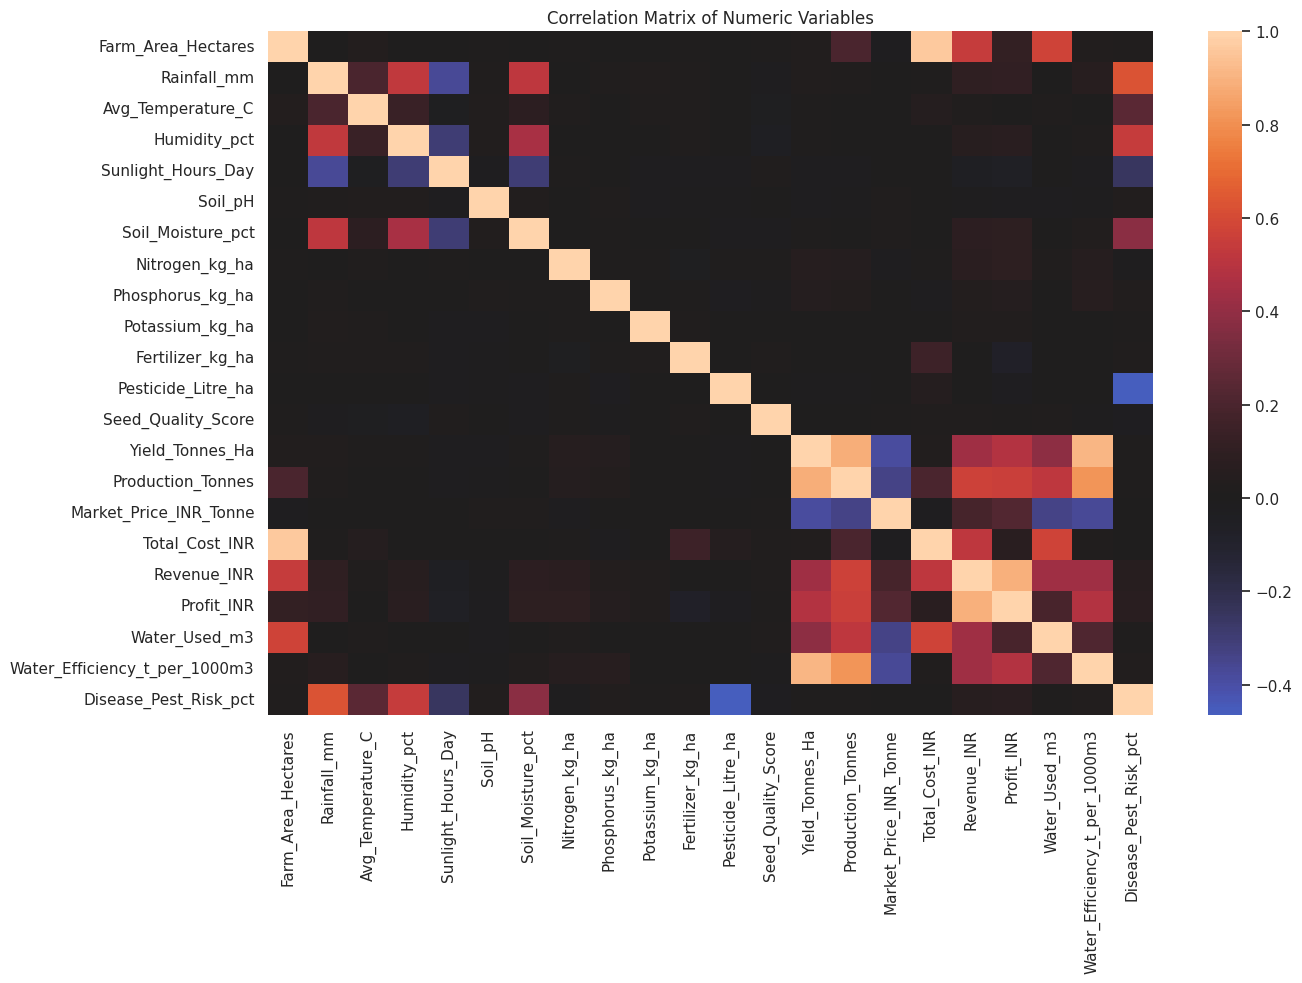

In [21]:
# Correlation matrix
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, center=0)
plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()

Yield is strongly correlated with production (r=0.88) and water efficiency (r=0.91). Profit is strongly correlated with
revenue (r=0.89) and moderately correlated with yield (r=0.49).

The very high yield–water-efficiency relationship should be interpreted carefully because water efficiency is derived
from production and water use. It is therefore not an independent environmental driver.

## 9.1 Yield and Production Scatter Plot

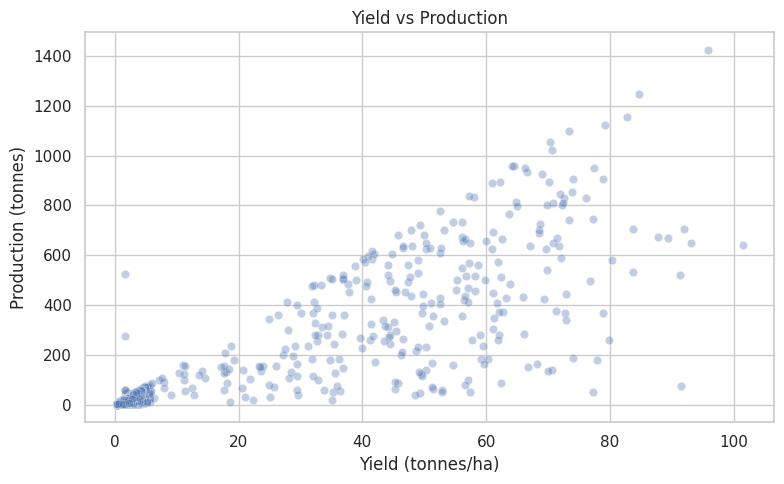

In [22]:
# Yield versus production
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Production_Tonnes",
    alpha=0.35
)
plt.title("Yield vs Production")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()

Production generally rises as yield rises, but farm area also affects production, so yield alone does not determine total
production.

## 10. Regional Consistency of Seasonal Patterns

The state-by-season average profit table helps determine whether the overall seasonal pattern is consistent across
regions.

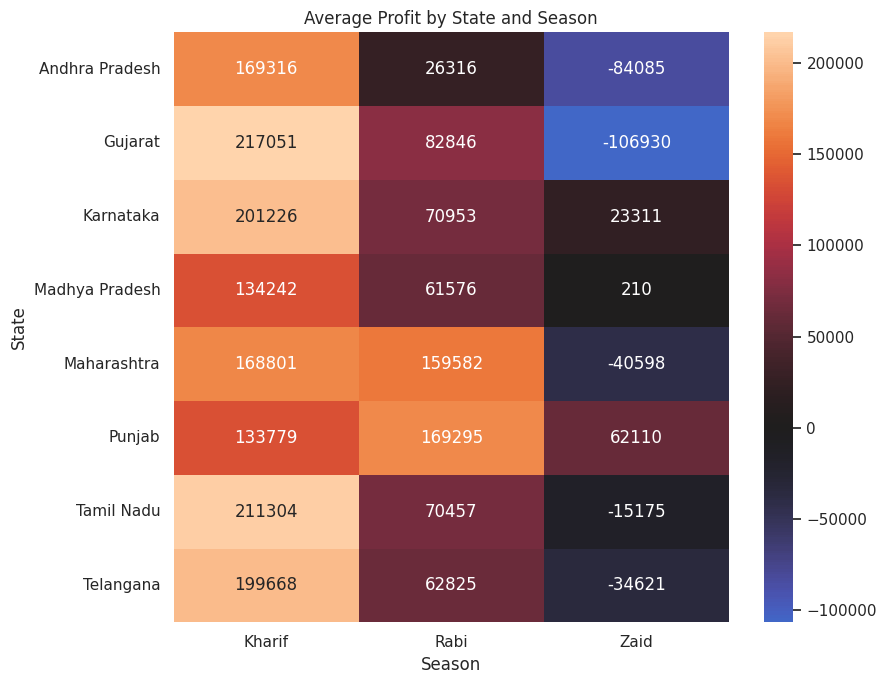

In [23]:
# Average profit by state and season
state_season_profit = df.pivot_table(
    index="State",
    columns="Season",
    values="Profit_INR",
    aggfunc="mean"
).reindex(columns=["Kharif", "Rabi", "Zaid"])
state_season_profit.round(0)
plt.figure(figsize=(9, 7))
sns.heatmap(state_season_profit, annot=True, fmt=".0f", center=0)
plt.title("Average Profit by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.tight_layout()
plt.show()

The broad Kharif advantage appears in many states, but regional differences are visible. Zaid is negative on average in
Andhra Pradesh, Gujarat, Maharashtra, Tamil Nadu, Telangana. Some states perform relatively better in Rabi or Zaid,
demonstrating that local crop mix and conditions can modify the overall seasonal pattern

## 11. Statistical Testing of Seasonal Differences

Because several variables have skewed distributions and large ranges, the Kruskal-Wallis test is used to compare the
distributions of each metric across Kharif, Rabi and Zaid. The null hypothesis is that the seasonal distributions are the
same

In [25]:
# Kruskal-Wallis test across seasons
metrics = [
    "Yield_Tonnes_Ha", "Profit_INR", "Revenue_INR",
    "Water_Used_m3", "Water_Efficiency_t_per_1000m3",
    "Rainfall_mm", "Avg_Temperature_C",
    "Humidity_pct", "Disease_Pest_Risk_pct"
]

for metric in metrics:
    groups = [
        df.loc[df["Season"] == season, metric].dropna()
        for season in ["Kharif", "Rabi", "Zaid"]
    ]
    H, p = kruskal(*groups)
    print(metric, "H =", round(H, 2), "p =", p)

Yield_Tonnes_Ha H = 70.17 p = 5.804276837546042e-16
Profit_INR H = 101.93 p = 7.362721866797111e-23
Revenue_INR H = 40.85 p = 1.3502813297517004e-09
Water_Used_m3 H = 5.97 p = 0.050567375805567014
Water_Efficiency_t_per_1000m3 H = 56.81 p = 4.608331719759396e-13
Rainfall_mm H = 2600.14 p = 0.0
Avg_Temperature_C H = 2385.97 p = 0.0
Humidity_pct H = 1845.51 p = 0.0
Disease_Pest_Risk_pct H = 1430.91 p = 1.913428882117e-311


At the 5% significance level, yield, profit, revenue, water efficiency, rainfall, temperature, humidity and disease/pest risk
show statistically significant differences across seasons. Water use is borderline (p » 0.05), so total water volume is
less clearly season-dependent than water efficiency. Statistical significance does not automatically imply practical
importance; the size and direction of differences should be considered alongside the descriptive results and graphs.

# 12. Answers to the Project Key Questions
## Q1. How does agricultural performance vary across seasons?

Kharif leads on average yield (5.63 t/ha), revenue, profit and profitability rate. Rabi is intermediate, while Zaid has the
weakest average economic performance.

## Q2. What major seasonal patterns can be observed?
Kharif combines higher rainfall (852.1 mm) and humidity with the strongest economic outcomes. Zaid is hotter and drier
and has negative average profit.

## Q3. Which characteristics change between seasons?
Rainfall, temperature, humidity, disease/pest risk, yield, revenue, profit and water efficiency show clear seasonal
differences.

## Q4. What differences exist between agricultural activities in different
seasons?
Crop mix, irrigation conditions and environmental exposure differ between seasons. These composition effects
contribute to differences in aggregate yield and profit.

## Q5. Are there noticeable variations in resource usage across seasons?
Average water use ranges from about 5,847 to 6,420 m³, while water efficiency differs more clearly across seasons.

## Q6. Are there relationships between seasonal environmental conditions and
agricultural performance?
Yes at the group level: seasons differ strongly in rainfall, temperature, humidity and risk, while performance also
changes. However, simple row-level environmental-to-yield correlations are weaker than the seasonal group
differences.

## Q7. How do economic outcomes vary across seasons?
Average profit falls from INR 178,915 in Kharif to INR 87,689 in Rabi and INR -24,805 in Zaid. Profitability falls from
57.8% to 48.9% to 35.5%.

## Q8. Are some seasonal patterns consistent across different regions or
categories?
The Kharif advantage is visible across many states, but exceptions show that regional crop composition and local
conditions matter.

## Q9. Are there unusual or unexpected seasonal patterns?
Kharif has the highest disease/pest risk (54.5%) while also having the strongest average economic performance. Total
water use is less strongly separated across seasons than water efficiency.

## Q10. What insights can be derived from the observed seasonal differences?
Seasonal planning should combine crop selection, irrigation efficiency, cost control and pest management rather than
relying on a single environmental variable.

## Q11. What conclusions can reasonably be drawn from the available data?
Season is strongly associated with environmental conditions and economic outcomes in this dataset. Crop and
irrigation method are also important descriptive factors. The analysis supports association, not causation.

## Q12. How could the findings support better seasonal agricultural planning?
Resources can be prioritized toward profitable crop-season combinations, efficient irrigation where appropriate,
stronger Kharif pest monitoring and tighter cost/risk control in Zaid.

# 13. Key Findings

• Kharif has the strongest overall performance: mean yield 5.63 t/ha, mean profit INR 178,915, and 57.8% profitable
farms.                                                                 
• Zaid is the weakest season economically: mean profit INR -24,805 and 35.5% profitable farms.                                                        
• Rainfall changes sharply by season: approximately 852 mm in Kharif, 436 mm in Rabi and 299 mm in Zaid.                                     
• Disease/pest risk is highest in Kharif at 54.5%.                     
• Drip has the highest average yield (6.58 t/ha), while Drip has the highest average profit (INR 219,626).                                  
• Sugarcane and Chilli are the most profitable crops on average, while wheat, rice and maize have negative average
profits.                                                               
• Regional results broadly follow the seasonal pattern, but important exceptions show that local crop mix and conditions
matter.                                                                
• Non-parametric testing confirms statistically significant seasonal differences for most key performance and
environmental variables.

# 14. Recommendations
• Prioritize crop-season combinations with demonstrated profitability rather than applying the same plan across every
season.                                                               
• Strengthen pest and disease monitoring during Kharif because disease/pest risk is highest even when profitability is
strong.                                                               
• Improve Zaid economics through cost control, crop selection and water-management strategies because Zaid has the
lowest profitability rate.                                             
• Encourage efficient irrigation where agronomically suitable; compare yield, profit and water efficiency together rather
than using one metric alone.                                           
• Use region-specific seasonal planning because statewide results are not identical.                                                            
• Evaluate crop-specific results before interpreting aggregate yield because high-yield crops such as sugarcane can
strongly affect the overall mean.                                          
• Track profit and profitability rate together with yield. High production or yield alone does not guarantee a positive
economic outcome.

# 15. Conclusion
The analysis demonstrates that seasonal agricultural performance is multidimensional. Kharif generally provides the
strongest economic outcomes, Rabi is intermediate, and Zaid is more challenging. Environmental conditions also
change substantially between seasons, and crop and irrigation choices are associated with meaningful differences in
performance.
The most useful planning approach is therefore not simply to maximize yield, but to balance crop choice, profitability,
water efficiency, costs and seasonal risk. The supplied dataset supports clear evidence-based seasonal comparisons
while also showing why region- and crop-specific analysis is necessary.

Scope Note: This project uses descriptive/statistical data analytics only. It does not build predictive machine-learning
models or dashboards.

# Appendix A — Complete Plotting Code
The following appendix keeps the graph-generating code together so that every visual in the report can be reproduced
directly in Google Colab/Jupyter.

## A1. Record Distribution

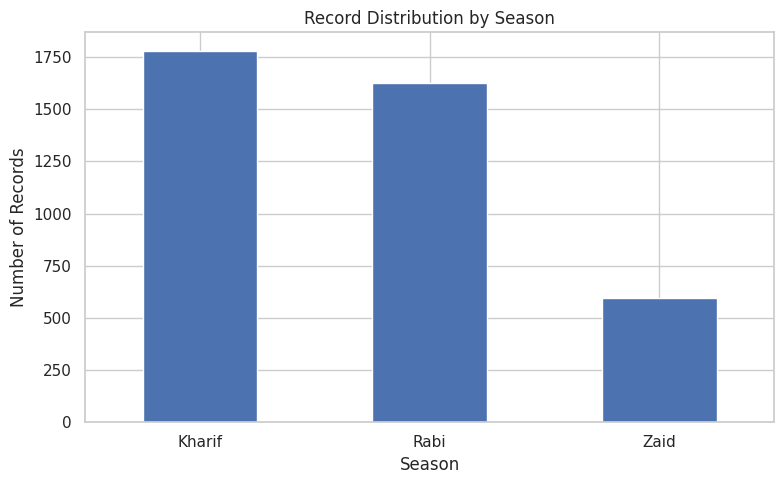

In [26]:
# Record distribution by season
season_counts = df["Season"].value_counts().reindex(
    ["Kharif", "Rabi", "Zaid"]
)
plt.figure(figsize=(8, 5))
ax = season_counts.plot(kind="bar")
plt.title("Record Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## A2. Yield Distribution

In [ ]:
# Yield distribution by season
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    order=["Kharif", "Rabi", "Zaid"],
    showfliers=False
)
plt.title("Yield Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

## A3. Average Profit by Season

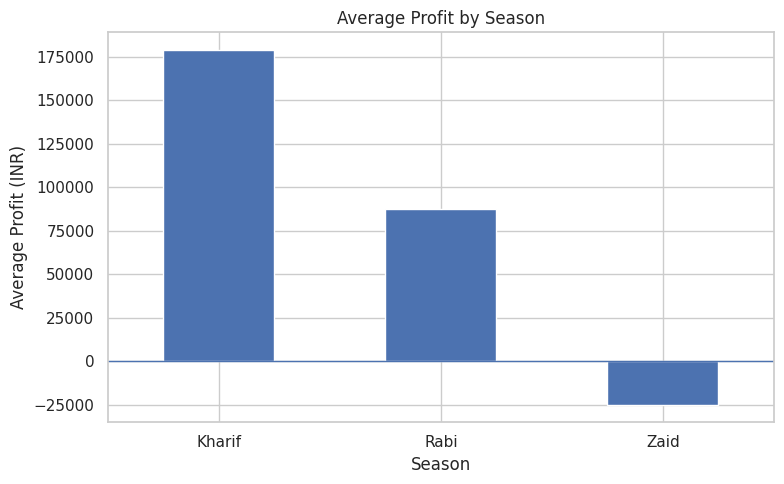

In [28]:
# Average profit by season
profit_by_season = df.groupby("Season")["Profit_INR"].mean().reindex(
    ["Kharif", "Rabi", "Zaid"]
)
plt.figure(figsize=(8, 5))
profit_by_season.plot(kind="bar")
plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

## A4. Environmental Profile

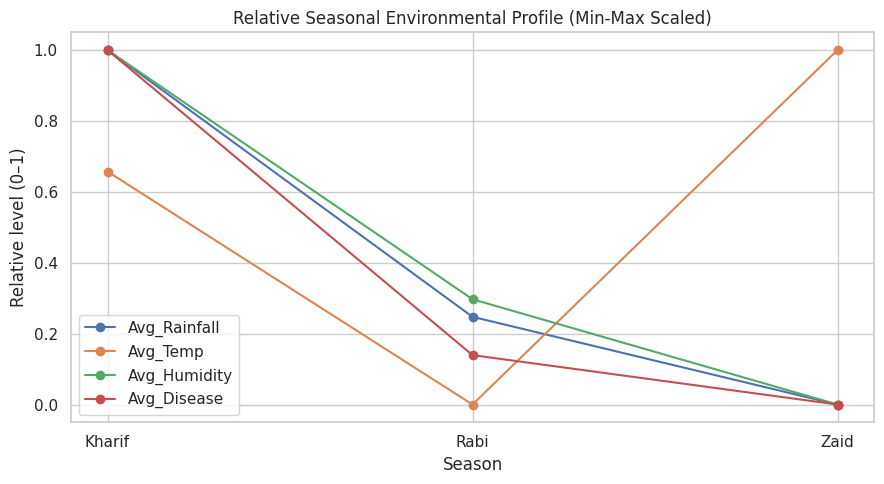

In [27]:
# Relative environmental profile
env = df.groupby("Season").agg(
    Avg_Rainfall=("Rainfall_mm", "mean"),
    Avg_Temp=("Avg_Temperature_C", "mean"),
    Avg_Humidity=("Humidity_pct", "mean"),
    Avg_Disease=("Disease_Pest_Risk_pct", "mean")
).reindex(["Kharif", "Rabi", "Zaid"])
env_scaled = (env - env.min()) / (env.max() - env.min())
plt.figure(figsize=(9, 5))
for col in env_scaled.columns:
    plt.plot(env_scaled.index, env_scaled[col],
             marker="o", label=col)
plt.title("Relative Seasonal Environmental Profile (Min-Max Scaled)")
plt.xlabel("Season")
plt.ylabel("Relative level (0–1)")
plt.legend()
plt.tight_layout()
plt.show()

## A5. Average Profit by Crop

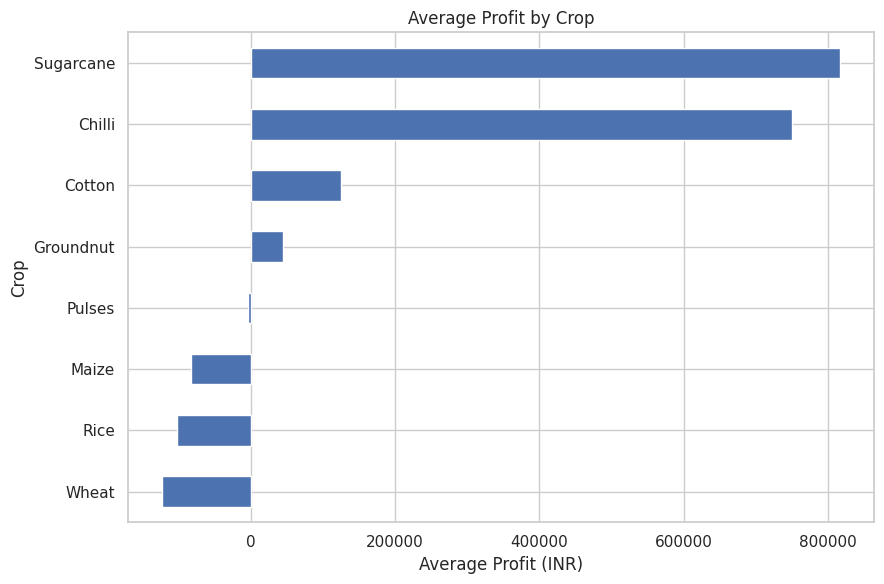

In [29]:
# Average profit by crop
plt.figure(figsize=(9, 6))
crop_summary["Avg_Profit"].sort_values().plot(kind="barh")
plt.title("Average Profit by Crop")
plt.xlabel("Average Profit (INR)")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

## A6. Water Efficiency by Irrigation

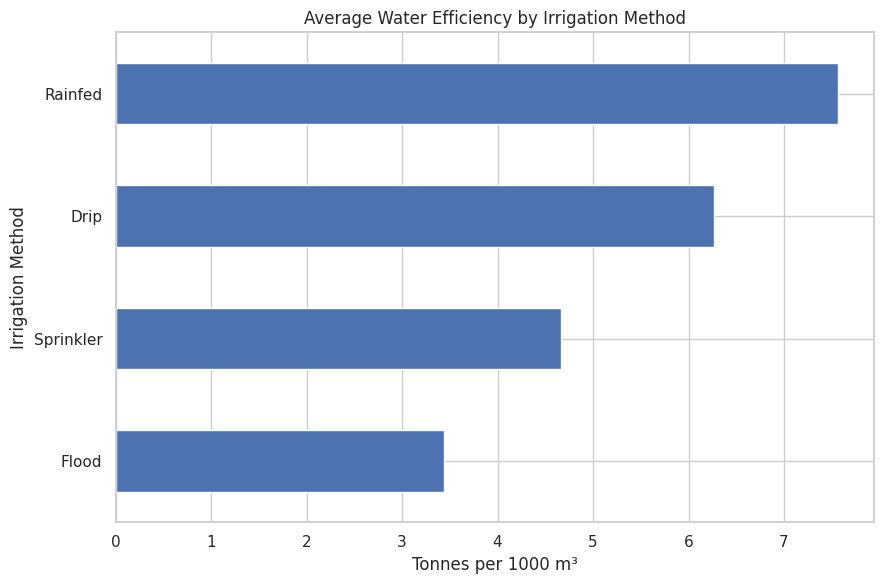

In [30]:
# Average water efficiency by irrigation method
plt.figure(figsize=(9, 6))
irrigation_summary["Avg_Eff"].sort_values().plot(kind="barh")
plt.title("Average Water Efficiency by Irrigation Method")
plt.xlabel("Tonnes per 1000 m³")
plt.ylabel("Irrigation Method")
plt.tight_layout()
plt.show()

## A7. Correlation Matrix

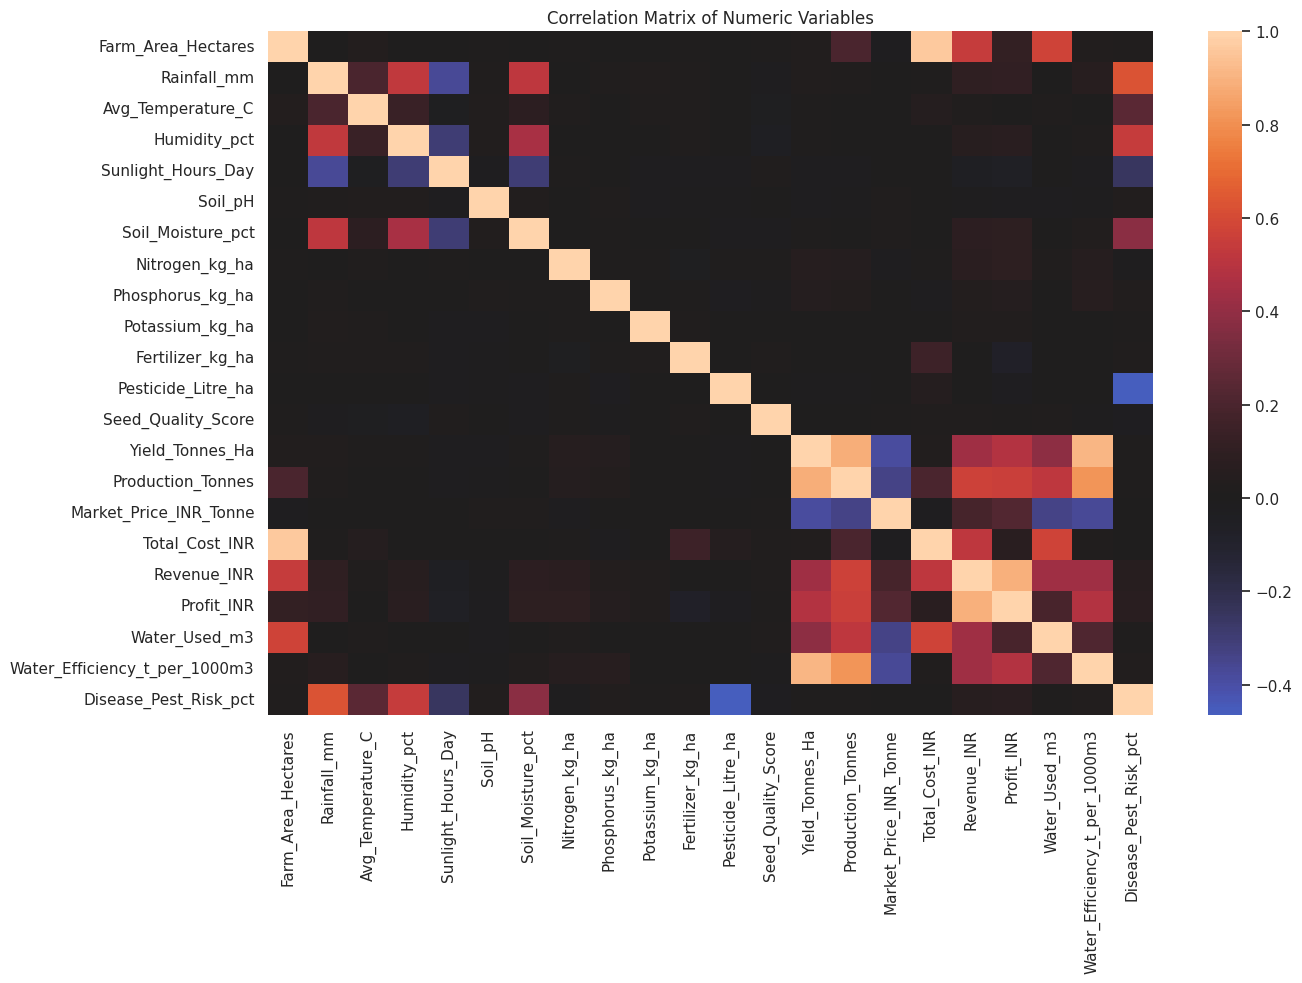

In [31]:
# Correlation matrix
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, center=0)
plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()

## A8. Yield vs Production

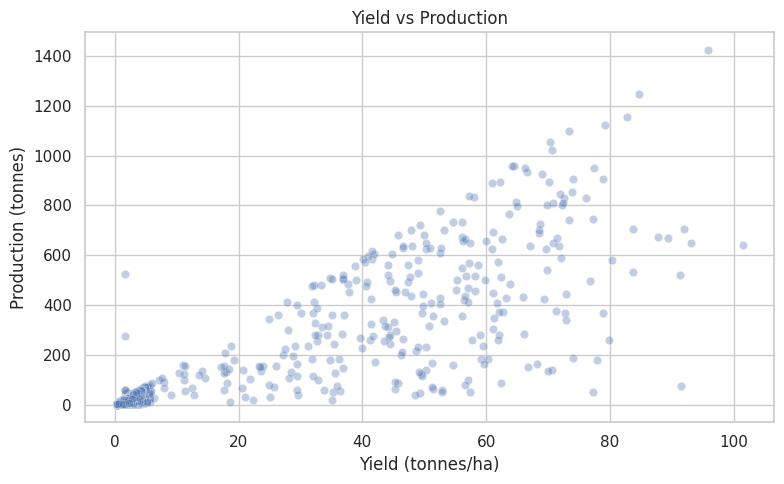

In [32]:
# Yield versus production
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Production_Tonnes",
    alpha=0.35
)
plt.title("Yield vs Production")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()

## A9. State × Season Profit Heatmap

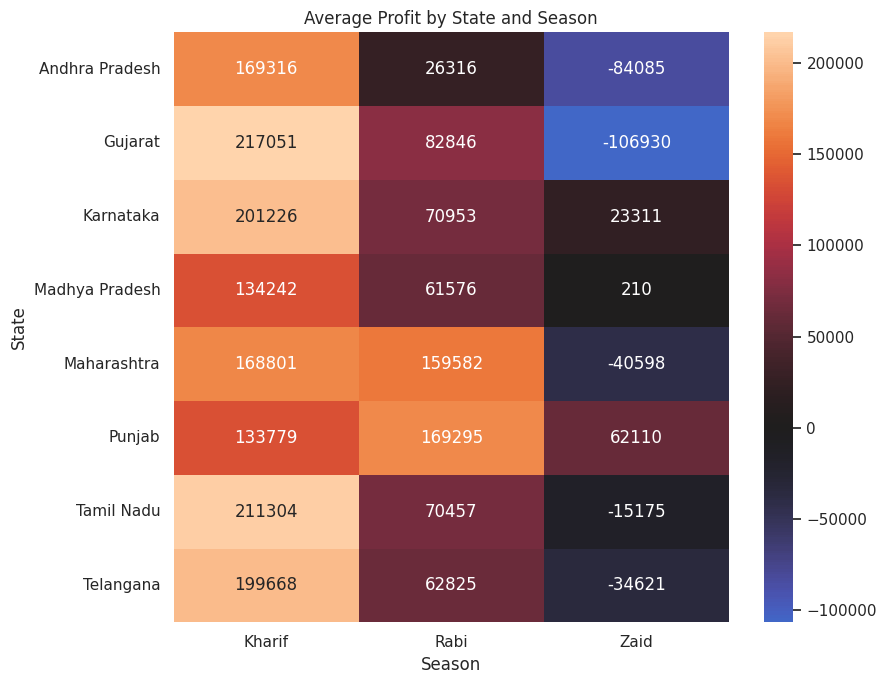

In [33]:
# Average profit by state and season
state_season_profit = df.pivot_table(
    index="State",
    columns="Season",
    values="Profit_INR",
    aggfunc="mean"
).reindex(columns=["Kharif", "Rabi", "Zaid"])
state_season_profit.round(0)
plt.figure(figsize=(9, 7))
sns.heatmap(state_season_profit, annot=True, fmt=".0f", center=0)
plt.title("Average Profit by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.tight_layout()
plt.show()